In [51]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1. Tickers (5 companies)
# ---------------------------
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

# ---------------------------
# 2. Download data
# ---------------------------
data = yf.download(tickers, start="2023-01-01")["Close"]

# ---------------------------
# 3. Loop through each stock
# ---------------------------
for ticker in tickers:
    
    df = pd.DataFrame()
    df["Close"] = data[ticker].dropna()

    # ---------------------------
    # Moving Averages
    # ---------------------------
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA50"] = df["Close"].rolling(50).mean()

    # ---------------------------
    # RSI
    # ---------------------------
    delta = df["Close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()

    rs = gain / loss
    df["RSI"] = 100 - (100 / (1 + rs))

    # ---------------------------
    # MACD
    # ---------------------------
    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()

    df["MACD"] = ema12 - ema26
    df["Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

[*********************100%***********************]  5 of 5 completed


Price + MA (relationship view)

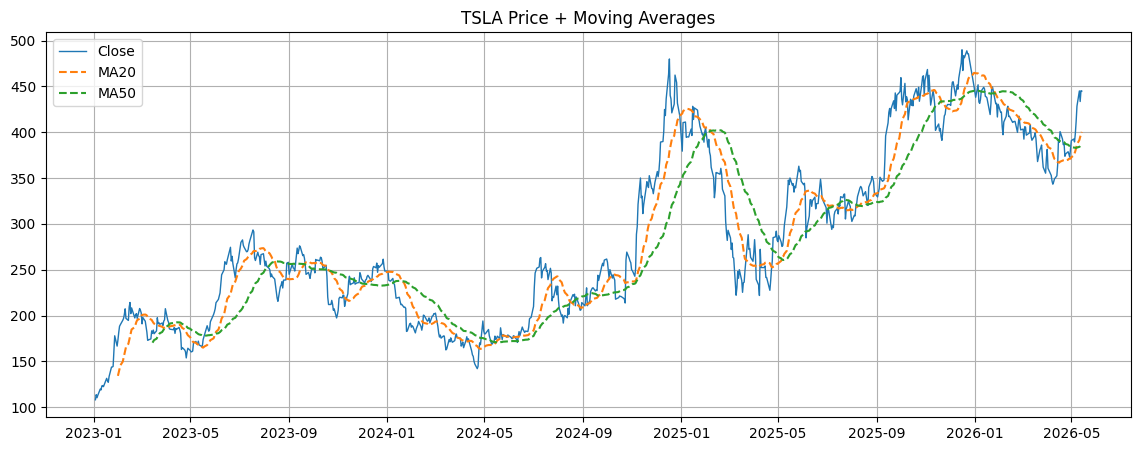

In [52]:
 # =====================================================
    # 📈 1. Price + Moving Averages
    # =====================================================
plt.figure(figsize=(14,5))
plt.plot(df["Close"], label="Close", linewidth=1)
plt.plot(df["MA20"], label="MA20", linestyle="--")
plt.plot(df["MA50"], label="MA50", linestyle="--")

plt.title(f"{ticker} Price + Moving Averages")
plt.legend()
plt.grid()
plt.show()

In [53]:
Price + RSI

NameError: name 'Price' is not defined

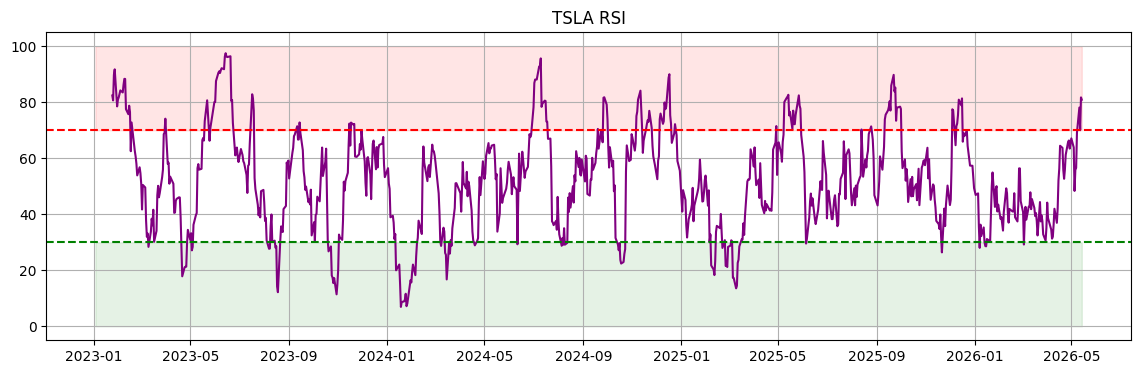

In [ ]:
    # 📊 2. RSI
    
plt.figure(figsize=(14,4))
plt.plot(df["RSI"], color="purple")

plt.axhline(70, color="red", linestyle="--")
plt.axhline(30, color="green", linestyle="--")

plt.fill_between(df.index, 70, 100, color="red", alpha=0.1)
plt.fill_between(df.index, 0, 30, color="green", alpha=0.1)

plt.title(f"{ticker} RSI")
plt.grid()
plt.show()

Price + MACD

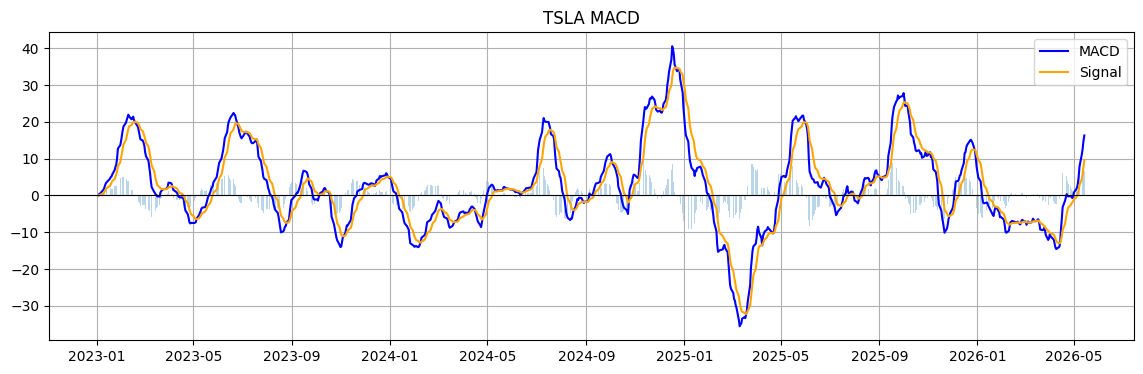

In [ ]:
   # 📉 3. MACD
   
plt.figure(figsize=(14,4))
plt.plot(df["MACD"], label="MACD", color="blue")
plt.plot(df["Signal"], label="Signal", color="orange")

plt.bar(df.index, df["MACD"] - df["Signal"], alpha=0.3)
plt.axhline(0, color="black", linewidth=0.8)

plt.title(f"{ticker} MACD")
plt.legend()
plt.grid()
plt.show()